## Cyberbulling Detection - Data Perprocessing 

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 1: Load Dataset
Loading the cyberbullying tweets dataset from Kaggle.

In [2]:
# Load dataset
df = pd.read_csv('../dataset/cyberbullying_tweets.csv')
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
df.head()

Dataset Shape: (47656, 3)

Column Names: ['tweet_text', 'cyberbullying_type', 'cleaned_text']


,tweet_text,cyberbullying_type,cleaned_text
0,"In other words #katandandre, your food was cra...",not_cyberbullying,in other words katandandre your food was crapi...
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,why is aussietv so white mkr theblock imaceleb...
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,xochitlsuckkks a classy whore or more red velv...
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,jasongio meh p thanks for the heads up but no...
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,rudhoeenglish this is an isis account pretendi...


## Step 2: Exploratory Data Analysis (EDA)
Understanding the dataset structure and distribution.

In [3]:
# Basic information
print("Dataset Info:")
print(df.info())
print("\nStatistics:")
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 47656 entries, 0 to 47655
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   tweet_text          47656 non-null  str  
 1   cyberbullying_type  47656 non-null  str  
 2   cleaned_text        47535 non-null  str  
dtypes: str(3)
memory usage: 1.1 MB
None

Statistics:


,tweet_text,cyberbullying_type,cleaned_text
count,47656,47656,47535
unique,46006,6,45475
top,#NAME?,religion,mileycyrus miley cyrus causes controversy with...
freq,12,7997,17


In [4]:
# Check class distribution
print("Cyberbullying Types:")
print(df['cyberbullying_type'].value_counts())

Cyberbullying Types:
cyberbullying_type
religion               7997
age                    7992
ethnicity              7959
gender                 7948
not_cyberbullying      7937
other_cyberbullying    7823
Name: count, dtype: int64


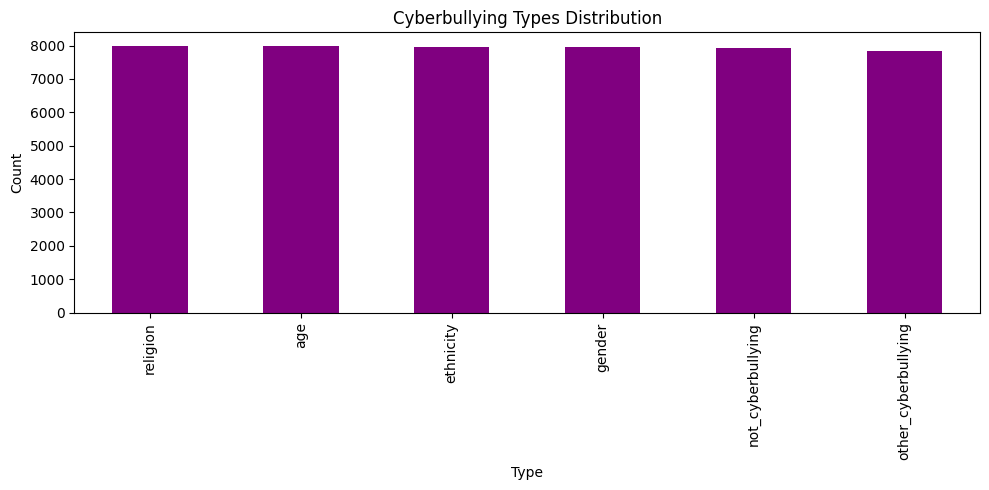

In [5]:
# Visualize class distribution
plt.figure(figsize=(10,5))
df['cyberbullying_type'].value_counts().plot(kind='bar', color='purple')
plt.title('Cyberbullying Types Distribution')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Step 3: Handle Missing Values and Duplicates

In [6]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove missing values and duplicates
df = df.dropna()
df = df.drop_duplicates()
print("\nClean Dataset Shape:", df.shape)

Missing Values:
tweet_text              0
cyberbullying_type      0
cleaned_text          121
dtype: int64

Duplicate Rows: 0

Clean Dataset Shape: (47535, 3)


## Step 4: Text Preprocessing
Cleaning tweet text for better model performance.

In [7]:
import re

def clean_text(text):
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove extra spaces
    text = text.strip()
    return text

# Apply cleaning
df['cleaned_text'] = df['tweet_text'].apply(clean_text)
print("Text cleaning completed!")
df[['tweet_text', 'cleaned_text']].head()

Text cleaning completed!


,tweet_text,cleaned_text
0,"In other words #katandandre, your food was cra...",in other words katandandre your food was crapi...
1,Why is #aussietv so white? #MKR #theblock #ImA...,why is aussietv so white mkr theblock imaceleb...
2,@XochitlSuckkks a classy whore? Or more red ve...,xochitlsuckkks a classy whore or more red velv...
3,"@Jason_Gio meh. :P thanks for the heads up, b...",jasongio meh p thanks for the heads up but no...
4,@RudhoeEnglish This is an ISIS account pretend...,rudhoeenglish this is an isis account pretendi...


## Step 5: Save Cleaned Dataset

In [8]:
# Save cleaned dataset
df.to_csv('../dataset/cleaned_dataset.csv', index=False)
print("Cleaned dataset saved successfully!")
print("Final Shape:", df.shape)

Cleaned dataset saved successfully!
Final Shape: (47535, 3)
